# Ch08.차원 축소

많은 경우, 데이터셋은 수천,수백만 개의 변수를 가지고 있다. 수 많은 변수는 훈련을 느리게 하고 좋은 솔루션을 찾기 어렵게 만든다. 이런 문제를 **차원의 저주(curse of dimensionality)** 라고 한다.

실전에서는 변수의 수를 크게 줄여 가능한 범위로 변경할 수 있다. 차원 축소는 훈련 속도를 높이는 것 외에도 시각화에 유용하다. 차원 수를 둘 또는 셋으로 줄이면 고차원 훈련 세트를 하나의 압축된 그래프로 그릴 수 있고 군집 같은 시각적인 패턴을 감지해 중요한 인사이트를 얻는 경우가 많다. 이번 장에서는 먼저 차원의 저주에 대해 살펴보고 고차원 공간에서 어떤 일이 일어나는지 살펴본다. 그 다음 여러 차원 축소 기법에 대해 살펴본다.

In [7]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib as mpl
import matplotlib.font_manager as fm
plt.rc('font', family='Malgun Gothic')  
plt.rcParams['axes.unicode_minus'] = False 
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

darker_hot = ListedColormap(plt.cm.hot(np.linspace(0, 0.8, 256)))

---

## 8.1 차원의 저주

우리는 3차원 세계에 살고 있어서 고차원 공간을 직관적으로 이해하기 어렵다. 단위 면적$(1 \times 1)$에서 임의의 두 점을 선택하면 두 점 사이의 거리는 평균적으로 대략 0.52이며, 3차원 큐브에선 대략 0.66이다.

하지만 만약 1,000,000차원의 단위 면적을 가진 초입방체에서 두 점을 랜덤으로 선택하면 평균 거리가 약 408.25이다. **고차원은 더 많은 공간을 가지고 있기 때문이다.** 이로 인해 고차원 데이터셋의 공간은 샘플끼리 매우 떨어져있는 희박한 공간일 것이다. 이는 새로운 샘플도 훈련 샘플과 멀리 떨어져 있을 가능성이 높다는 뜻이며, 이는 **모델이 정확한 예측을 하지 못하는 문제**를 부른다.

이론적으로 차원의 저주를 해결하는 해결책 하나는 훈련 샘플의 밀도가 충분히 높아질 때까지 훈련 세트의 크기를 키우는 것이다. 하지만 실제로는 일정 밀도에 도달하기 위해 필요한 훈련 샘플 수는 차원 수가 커짐에 따라 기하급수적으로 늘어난다. 

---

## 8.2 차원 축소를 위한 접근법

구체적인 차원 축소 알고리즘을 알아보기 전에 차원을 감소시키는 두 가지 주요한 접근법인 투영과 매니폴드 학습을 살펴본다.

### 투영(Projection)

대부분의 실제 문제는 훈련 샘플이 모든 차원에 걸쳐 균일하게 퍼져 있지 않다. 많은 변수들은 거의 변화가 없는 반면, 다른 변수들은 서로 강하게 연관되어 있다. 결과적으로 모든 훈련 샘플이 고차원 공간 안의 저차원 **부분 공간(subspace)** 에, 혹은 부분 공간 가까이에 놓여 있다.

<center>

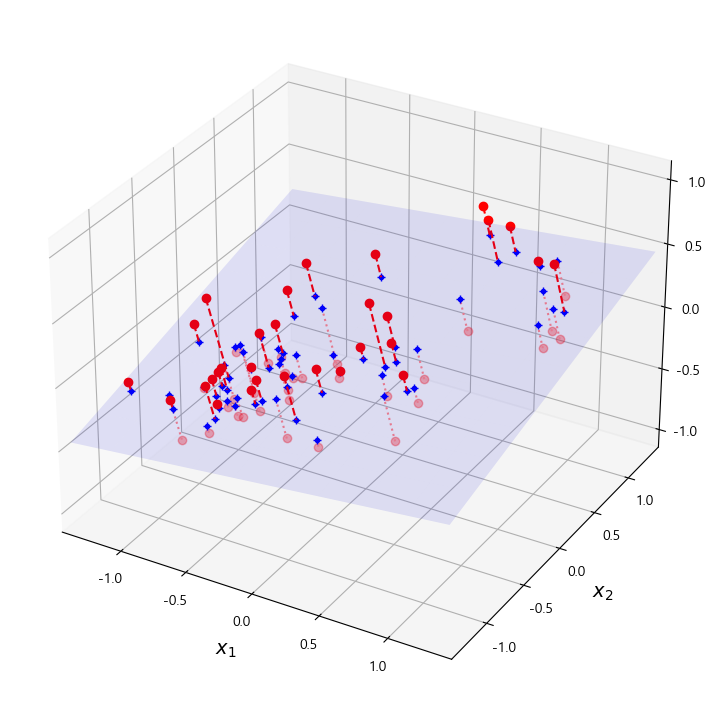

</center>

위의 3차원 데이터셋을 보면 모든 훈련 샘플이 거의 평면 형태로 놓여 있다. 이것이 3차원 공간에 있는 저차원 부분 공간이다. 여기서 모든 훈련 샘플을 샘플과 평면 사이를 연결한 점선으로 부분 공간에 수직으로 투영하면 다음과 같은 2차원 데이터셋을 얻을 수 있다. 각 축은 평면에 투영된 좌표인 새로운 특성 $z_1$과 $z_2$에 대응된다.

<center>

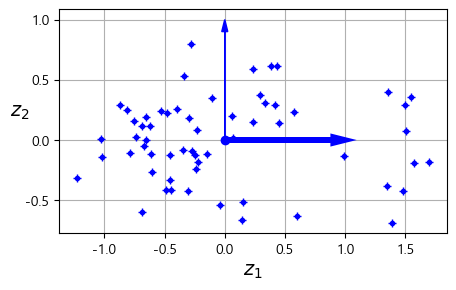

</center>

그러나 차원 축소에 투영이 언제나 최선의 방법은 아니다. 많은 경우 다음 그림과 같이 **스위스 롤**처럼 부분 공간이 뒤틀리거나 휘어 있기도 하다.

<center>

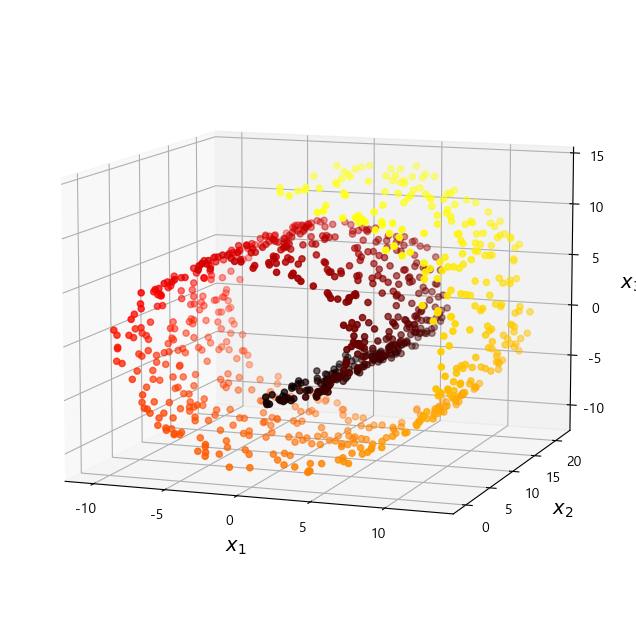

</center>

이를 그냥 $x_3$축을 버리고 평면에 투영시키면 다음 왼쪽 그림처럼 스위스 롤의 층이 서로 뭉개진다. 우리가 원하는 이상적인 것은 스위스 롤을 펼쳐서 오른쪽처럼 2차원으로 만드는 것이다.

<center>

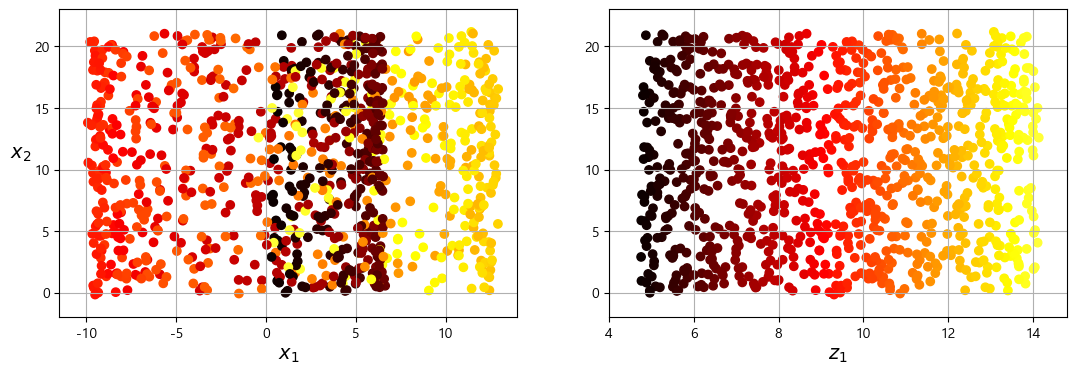

</center>

### 매니폴드 학습

스위스 롤은 2차원 매니폴드의 한 예시이다. 2차원 매니폴드는 고차원 공간에서 휘어지거나 뒤틀린 2차원 형태이다.  
이를 더 큰 차원으로 일반화하면, $d$차원 매니폴드는 국소적으로 $d$차원 초평면(hyperplane)으로 보일 수 있는 $n$차원 공간의 일부이다. 위의 스위스 롤의 경우 $d=2$이고, $n=3$이다. 국소적으로는 2차원 평면처럼 보이지만, 3차원으로 말려있다.

많은 차원 축소 알고리즘이 훈련 샘플이 놓여 있는 **매니폴드(manifold)** 를 모델링하는 식으로 작동한다. 이를 **매니폴드 학습**이라고 한다. 이는 대부분 실제 고차원 데이터셋이 더 낮은 저차원 매니폴드에 가깝게 놓여 있다는 **매니폴드 가정**에 근거하며, 경험적으로도 이 가정이 맞는 경우도 자주 발견된다.

MNIST 데이터셋을 예시로 생각해본다. 전체 손글씨 숫자 이미지는 어느 정도 비슷한 면이 있다. 선으로 연결되어 있고, 경계는 흰색이고 어느 정도 중앙에 있다. 랜덤으로 생성된 이미지라면 그 중 아주 적은 일부만 손글씨 숫자처럼 보일 것이다. 즉, 숫자 이미지를 만들 때 가능한 자유도는 아무 이미지나 생성할 때의 자유도보다 훨씬 낮다. 이런 제약은 데이터셋을 저차원의 매니폴드로 압축할 수 있도록 도와준다.

매니폴드 가정은 종종 암묵적으로 지도 학습이 저차원의 매니폴드 공간에 표현되면 더 간단해질 것이라는 가정과 같이 사용된다.

<center>

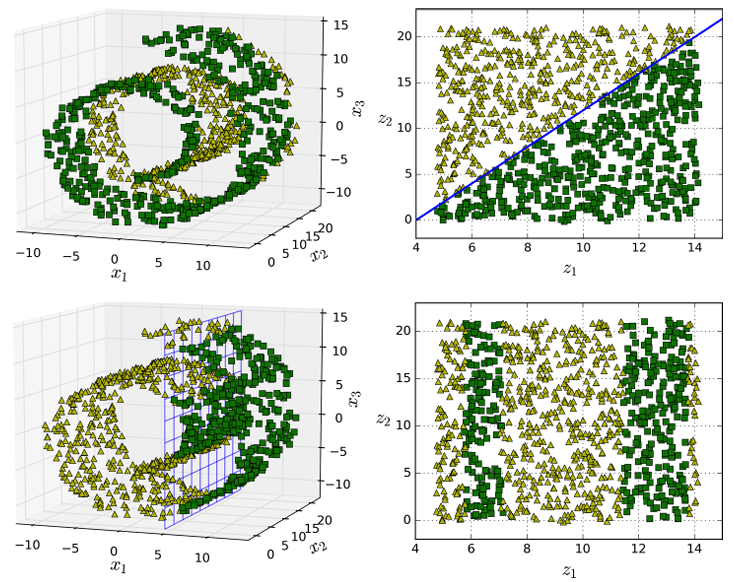

</center>

위의 그림의 첫 번째 행에서는 스위스롤이 두 개의 클래스로 나뉘어 있다. 왼쪽에서는 결정 경계가 매우 복잡하지만, 펼쳐진 매니폴드에서는 결정 경계가 단순한 직선이다. 하지만 이런 가정이 항상 유효하지는 않다. 위 그림의 두 번째 행을 보면 오히려 3차원 공간에서의 결정 경계가 단순한 반면, 펼쳐진 경우 결정 경계가 더욱 복잡하다.

따라서 모델을 훈련시키기 전에 훈련 세트의 차원을 감소시키면 훈련 속도는 빨라지지만 항상 더 낫거나 간단한 솔루션을 장담하지 않으며, 이는 전적으로 데이터셋에 달렸다.

---

## 8.3 주성분 분석

**주성분 분석(Principle Component Analysis,PCA)** 은 가장 기본적이며, 자주 사용되는 차원 축소 알고리즘이다. 먼저 데이터에 가장 가까운 초평면을 정의한 다음, 데이터를 해당 평면에 투영시킨다.

### 분산 보존

저차원의 초평면에 훈련 세트를 투영하기 전에, 먼저 올바른 초평면을 선택해야 한다.

<center>

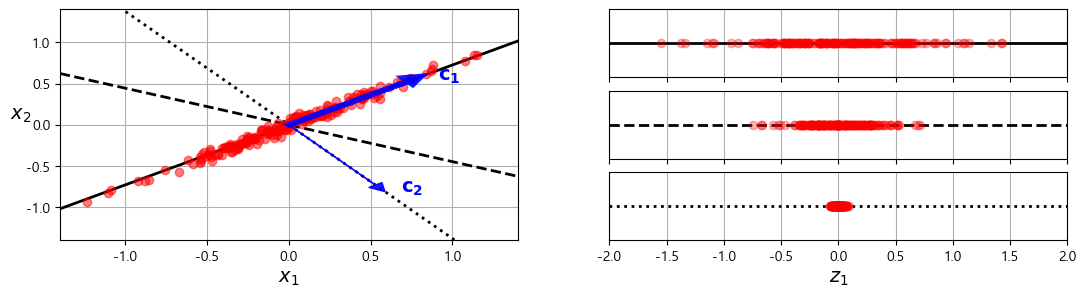

</center>

예를 들어 위 그림의 왼쪽 그래프는 간단한 2차원 데이터셋이 세 개의 축인 1차원 초평면과 함께 표현되어 있다. 오른쪽 그래프는 데이터셋이 각 축에 투영된 결과이다. 여기서 볼 수 있듯이 실선에 투영된 것은 분산을 최대로 보존하는 반면, 점선들에 투영된 것들은 이전보다 분산을 적게 유지하고 있다.

다른 방향으로 투영하는 것보다 분산이 최대로 보존되는 축을 선택하는 것이 **정보가 가장 적게 손실**된다. 이 선택을 다른 방식으로 설명하면, **원본 데이터셋과 투영된 것 사이의 평균 제곱 거리를 최소화하는 축**이다.

### 주성분

PCA는 훈련 세트에서 분산이 최대인 축을 찾는다. 또한 첫 번째 축에 직교하고 남은 분산을 최대한 보존하는 두 번째 축을 찾는다. 고차원 데이터셋이라면 PCA는 이전에 찾은 축에 직교하는 다른 축을 찾으며 데이터셋에 있는 차원의 수만큼 계속해서 축을 찾는다.

$i$번째 축을 이 데이터의 **$i$번째 주성분(Principle Component,PC)** 이라고 부른다. 위의 그림에서 첫 번째 PC는 벡터 $\bold c_1$이 놓인 축이고, 두 번째 PC는 벡터 $\bold c_2$가 놓인 축이다.

<center>

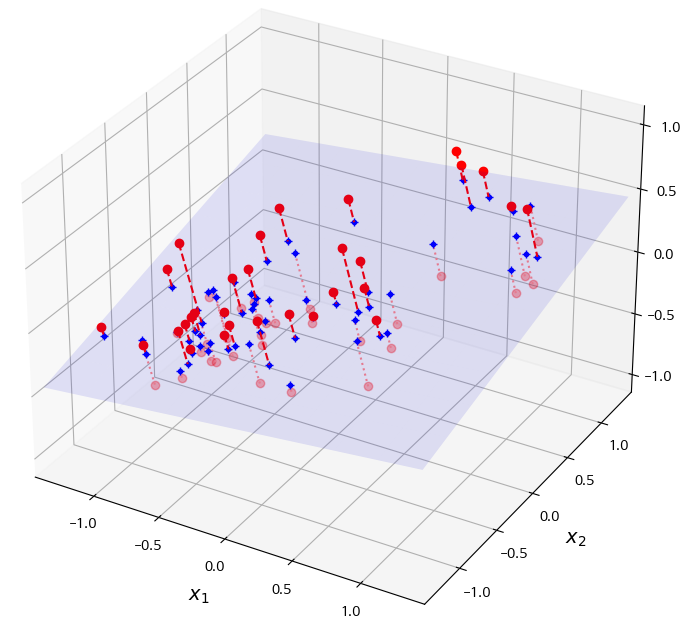

</center>

위의 그림에서는 처음 두 개의 PC가 투명 평면에 있으며 세 번째 PC가 이 평면에 수직인 축이다. 투영된 후 다음 그림에서 첫 번째 PC가 $z_1$이고 두 번째 PC가 $z_2$에 해당한다.

<center>

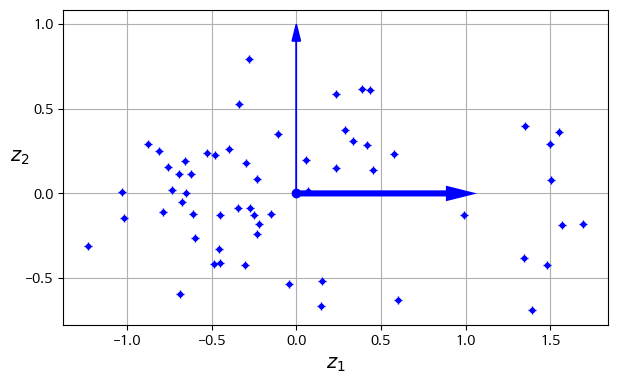

</center>

각 주성분을 위해 PCA는 주성분 방향을 가리키고 원점에 중앙이 맞춰진 단위 벡터를 찾는다. 하나의 축에 단위 벡터가 반대 방향으로 두 개가 있으므로 PCA가 반환하는 단위 벡터의 방향은 일정하지 않으므로, 주성분의 방향 또한 일정하기 않다. 훈련 세트를 조금 섞은 다음 다시 PCA를 적용하면 새로운 PC 중 일부가 원래 PC와 반대 방향일 수 있으나, 일반적으로 같은 축에 놓여 있을 것이다. 어떤 경우에는 한 쌍의 PC가 회전하거나 서로 바뀔 수 있지만 보통은 같은 평면을 구성한다.

훈련 세트의 주성분은 행렬 분해 방법인 **특이값 분해(SVD)** 사용하여 훈련 세트 행렬 $\mathbf{x}$를 세 개의 행렬  $U\Sigma V^{T}$로 분해한다. 여기서 찾고자 하는 모든 주성분의 단위 벡터가 $V$에 다음과 같이 담겨 있다.
$$
V=\begin{bmatrix}
| & | & | \\
c_1 & c_2 & c_3 \\
| & | & |
\end{bmatrix}
$$

공분산 행렬의 **고유 벡터(Eigenvector)** 는 분산이 어느 방향으로 가장 큰지 나타낸다. 중앙에 맞춰진 훈련 세트의 공분산 행렬은 다음과 같다.
$$
Cov = \frac{1}{n-1} \mathbf{X}^{T} \mathbf{X} = \frac{1}{n-1} (U\Sigma V^T)^T(U\Sigma V^T) = \frac{1}{n-1} V \Sigma^2 V^T = V \frac{\Sigma^2}{n-1} V^T
$$

따라서 $V$가 공분산 행렬의 고유 벡터이고 주성분이 된다. 사이킷런의 PCA는 `scipy.linalg.svd` 함수를 사용하여 주성분 $V$를 구한다. 다만 `scipy.linalg.svd` 나 `numpy.linalg.svd` 함수에서 반환되는 `U,s,V` 값에서 `V`가 $V^T$이다.

다음 파이썬 코드는 넘파이의 `svd()` 함수를 사용해 3차원 훈련 세트의 모든 주성분을 구한 후 처음 두 개의 PC를 정의하는 두 개의 단위 벡터를 추출한다.

In [2]:
import numpy as np
from scipy.spatial.transform import Rotation

m = 60
X = np.zeros((m, 3))  
np.random.seed(42)
angles = (np.random.rand(m) ** 3 + 0.5) * 2 * np.pi  
X[:, 0], X[:, 1] = np.cos(angles), np.sin(angles) * 0.5  
X += 0.28 * np.random.randn(m, 3)  
X = Rotation.from_rotvec([np.pi / 29, -np.pi / 20, np.pi / 4]).apply(X)
X += [0.2, 0, 0.2]  

X_centered = X - X.mean(axis=0)
U,s,Vt = np.linalg.svd(X_centered)

c1=Vt[0]
c2=Vt[1]

PCA는 데이터셋의 평균이 0이라고 가정한다. 사이킷런의 PCA 클래스는 이 작업을 대신 처리해준다. PCA를 직접 처리하거나 다른 라이브러리를 상요한다면 먼저 데이터를 원점에 맞춰야 한다.

### $d$차원으로 투영

주성분을 모두 추출했다면 처음 $d$개의 주성분으로 정의한 초평면에 투영하여 데이터셋의 차원을 $d$차원으로 축소시킬 수 있다. 이 초평면은 분산을 가능한 한 최대로 보존하는 투영인 것을 보장한다.

초평면에 훈련 세트를 투영하고 $d$차원으로 축소된 데이터셋 $X_{d-proj}$을 얻기 위해선 다음 식으로 행렬 $X$와 $V$의 첫 $d$ 열로 구성된 행렬 $W_{d}$를 행렬곱하면 된다.
$$
X_{d-proj}=XW_d
$$

다음 파이썬 코드는 첫 두 개의 주성분으로 정의된 평면에 훈련 세트를 투영한다.

In [3]:
W2 = Vt[:2].T
X2D = X_centered @ W2

### 사이킷런에서 PCA

사이킷런의 PCA 모델은 앞서 한 것처럼 SVD를 사용하여 구현한다. 다음은 PCA 모델을 사용해 데이터셋의 차원을 2로 줄이는 코드이다. 사이킷런의 PCA는 자동으로 데이터를 중앙에 맞춰준다.

In [4]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X2D = pca.fit_transform(X)

PCA 변환을 데이터셋에 학습시키고 나면 `components_` 속성에 $W_d$의 전치가 담겨있다. 이 배열의 행은 처음 $d$개의 주성분에 해당한다.

### 설명된 분산의 비율

`explained_variance_ratio_` 변수에 저장된 주성분의 **설명된 분산의 비율**은 각 주성분의 축을 따라 있는 데이터셋의 분산 비율을 나타낸다. PCA의 주성분으로 설명된 분산은 공분산 행렬의 **고유값(eigenvalue)** 이며, 설명된 분산의 비율은 전체 분산에서 차지하는 비율이다.
$$
\frac{\Sigma^2}{n-1}
$$

In [5]:
pca.explained_variance_ratio_

array([0.7578477 , 0.15186921])

이는 훈련 데이터셋 분산의 76%가 첫 번째 PC를 따라 놓여 있고 15%가 두 번째 PC를 따라 놓여 있음을 알려준다. 세 번쨰 PC에는 9% 미만이 남아 있을 것이므로 아주 적은 양의 정보가 들어있다.

### 차원 수 선택

축소할 차원 수는 충분한 분산이 될 때까지 더해야 할 차원 수를 선택하는 것이 적절하다. 물론 시각화 목적이면 2,3차원으로 줄이면 된다.

다음 코드는 MNIST 데이터셋을 로드하고 분할한 다음, 차원을 줄이지 않고 PCA를 수행한다. 그 다음 훈련 세트의 분산 95%를 보존하는 데 필요한 최소 차원 수를 계산한다.

In [6]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784',as_frame=False)
X_train,y_train = mnist.data[:60_000],mnist.target[:60_000]
X_test,y_test =mnist.data[60_000:],mnist.target[60_000:]



pca = PCA() #n_components 지정하지 않으면 min(m,n)으로 설정
pca.fit(X_train)
cumsum = np.cumsum(pca.explained_variance_ratio_)
d = np.argmax(cumsum >= 0.95) + 1 

C:\Users\user\AppData\Roaming\Python\Python310\site-packages\sklearn\datasets\_openml.py:968: FutureWarning: The default value of `parser` will change from `'liac-arff'` to `'auto'` in 1.4. You can set `parser='auto'` to silence this warning. Therefore, an `ImportError` will be raised from 1.4 if the dataset is dense and pandas is not installed. Note that the pandas parser may return different data types. See the Notes Section in fetch_openml's API doc for details.
  warn(


다음으로 `n_components=d`로 설정하여 PCA를 다시 실행한다. 여기선 유지하려는 주성분의 수를 지정하기보다는 보존하려는 분산의 비율을 `n_components`에 0.0에서 1.0 사이로 설정하는 편이 훨씬 낫다.

In [7]:
pca = PCA(n_components=0.95)
X_reduced = pca.fit_transform(X_train)

실제 주성분 개수는 훈련 중에 결정되며 `n_components_` 속성에 저장된다.

In [8]:
pca.n_components_

154

또 다른 방법은 설명된 분산을 차원 수에 대한 함수로 그리는 것이다.

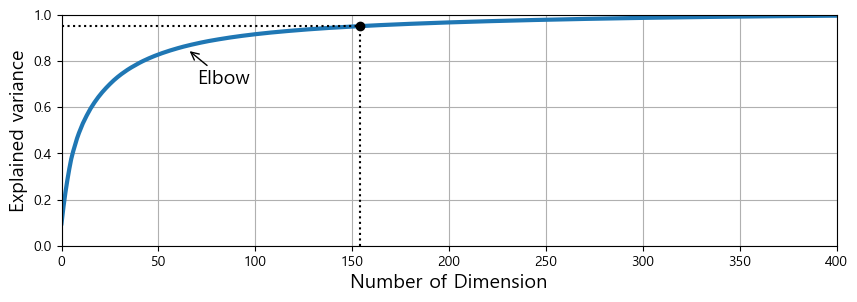

In [9]:
plt.figure(figsize=(10, 3))
plt.plot(cumsum, linewidth=3)
plt.axis([0, 400, 0, 1])
plt.xlabel("Number of Dimension")
plt.ylabel("Explained variance")
plt.plot([d, d], [0, 0.95], "k:")
plt.plot([0, d], [0.95, 0.95], "k:")
plt.plot(d, 0.95, "ko")
plt.annotate("Elbow", xy=(65, 0.85), xytext=(70, 0.7),
             arrowprops=dict(arrowstyle="->"))
plt.grid(True)
plt.show()

일반적으로 이 그래프에는 설명된 분산의 빠른 성장이 멈추는 변곡점이 있다. 여기서는 차원을 약 100으로 축소해도 설명된 분산을 크게 손해보지 않을 것이다.

지도학습 작업의 전처리 단계로 차원 축소를 사용하는 경우, 다른 하이퍼파라마미터와 마찬가지로 차원 수를 튜닝할 수도 있다. 예를 들어, 다음 드는 두 단계로 구성된 파이프라인을 생성한다. 먼저 PCA를 사용하여 차원을 줄인 다음 랜덤 포레스트를 사용하여 분류를 수행한다. 그런 다음 `RandomizedSearchCV`를 사용하여 PCA와 랜덤 포레스트 분류기에 잘 맞는 하이퍼파라미터 조합을 찾는다.

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import make_pipeline

clf = make_pipeline(PCA(random_state=42),
                    RandomForestClassifier(random_state=42))

param_dist = {
    'pca__n_components' : np.arange(10,80),
    'randomforestclassifier__n_estimators' : np.arange(50,500)
}

rnd_search = RandomizedSearchCV(clf, param_dist,n_iter=10,cv=3,random_state=42)

rnd_search.fit(X_train[:1000],y_train[:1000]);

앞에서 찾은 최상의 하이퍼파라미터 조합을 살펴본다.

In [11]:
print(rnd_search.best_params_)

{'randomforestclassifier__n_estimators': 465, 'pca__n_components': 23}


최적의 성분 수가 매우 적은 것을 알 수 있다. 784개 차원의 데이터셋을 단 23개 차원으로 줄였다.

### 압축을 위한 PCA

차원 축소 후 훈련 세트는 훨씬 적은 저장 공간을 차지한다. 95%의 분산을 유지하도록 MNIST 데이터 세트에 PCA를 적용하면 원래 784개의 변수 중에 154개의 변수만 남게 된다. 따라서 데이터셋의 크기는 원본의 20% 이하로 줄지만 분산은 5%만 손실되었다.

압축된 데이터셋에 PCA 투영의 변환을 반대로 적용하여 784개의 차원으로 되돌릴 수도 있다. 투영에서 일정량의 정보를 잃어버렸기 때문에 원본 데이터셋을 얻을 수는 없지만, 원본 데이터와 유사할 것이다. 원본 데이터와 재구성한 데이터(압축 후 원상 복구) 사이의 평균 제곱 거리를 **재구성 오차(reconstruction error)** 라고 한다.

`inverse_transform()` 메서드를 사용하면 축소된 MNIST 데이터 집합을 다시 784개 차원으로 복원할 수 있다.

In [12]:
X_recovered = pca.inverse_transform(X_reduced)

다음 그림의 왼쪽은 원본 훈련 세트, 왼쪽은 샘플을 압축한 후 복원한 결과를 보여준다. 이미지 품질이 조금 손실되었지만 숫자 모양은 거의 온전한 상태이다.

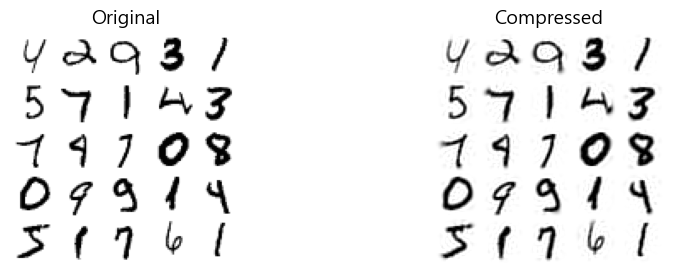

In [13]:
plt.figure(figsize=(10, 3))
for idx, X in enumerate((X_train[::2100], X_recovered[::2100])):
    plt.subplot(1, 2, idx + 1)
    plt.title(["Original", "Compressed"][idx])
    for row in range(5):
        for col in range(5):
            plt.imshow(X[row * 5 + col].reshape(28, 28), cmap="binary",
                       vmin=0, vmax=255, extent=(row, row + 1, col, col + 1))
            plt.axis([0, 5, 0, 5])
            plt.axis("off")

역변환 공식은 다음과 같다.
$$
X_{recovered}=X_{d-proj}W_d^T
$$

### 랜덤 PCA

`svd_solver` 파라미터를 `"randomized"` 로 지정하면 사이킷런은 랜덤 PCA라 부르는 확률적 알고리즘을 사용해 처음 $d$개의 주성분에 대한 근사값을 빠르게 찾는다.

이 알고리즘의 계산 복잡도는 완전한 SVD 방식인 $O(m \times n^2)+O(n^3)$이 아니라 $O(m \times d^2)+O(d^3)$이다. 따라서 $d$가 $n$보다 많이 작으면 완전 SVD보다 훨씬 빠르다.

In [14]:
rnd_pca = PCA(n_components=154,svd_solver='randomized',random_state=42)
X_reduced = rnd_pca.fit_transform(X_train)

`svd_solver`의 기본값은 `"auto"`이다. $max(m,n) \gt 500$이고 `n_components`가 $min(m,n)$의 80%보다 작은 정수인 경우 사이킷런은 자동으로 랜덤 PCA 알고리즘을 사용한다. 그렇지 않으면 완전 SVD 방식을 사용한다. 따라서 위의 코드는 $154 \lt 0.8 \times 784$이므로 `svd_solver="randomized"` 파라미터를 제거하더라도 랜덤 PCA 알고리즘을 사용하게 된다. 더 정확한 결과를 얻기 위해선 `svd_solver="full"`로 설정하면 된다.

### 점진적 PCA

PCA 구현의 문제는 SVD 알고리즘을 실행하기 위해 전체 훈련 세트를 메모리에 올려야 한다는 점이다. 이런 경우 **점진적 PCA(Incremental PCA,IPCA)** 알고리즘을 사용하면 점진적 학습이 가능하다.

훈련 세트를 미니배치로 나눈 뒤 IPCA 알고리즘에 한 번에 하나씩 주입한다. 훈련 세트가 크거나 새로운 데이터를 실시간으로 적용해야 할 때 사용 가능하다.

다음 코드는 MNIST 훈련 세트를 넘파이의 `array_split()` 함수를 사용해 100개의 미니배치로 나누고 사이킷런의 `IncrementalPCA` 파이썬 클래스에 주입하여 MNIST 데이터셋의 차원을 이전과 같은 154개로 줄인다. 전체 훈련 세트를 사용하는 `fit()` 메서드가 아니라 `partial_fit()` 메서드를 미니배치마다 호출해야 한다.

In [15]:
from sklearn.decomposition import IncrementalPCA

n_batch = 100
inc_pca = IncrementalPCA(n_components=154)
for X_batch in np.array_split(X_train,n_batch):
    inc_pca.partial_fit(X_batch);

X_reduced = inc_pca.transform(X_train)

---

## 8.4 커널 주성분 분석

SVM에서 커널 트릭이라는 기법으로, 실제 훈련 데이터를 변환하지 않고 고차원으로 매핑하여 회귀나 분류 작업을 수행한다. 기존의 변수 공간에서 복잡한 비선형 결정 경계가 고차원에서는 선형 함수가 된다.

이 커널 트릭은 PCA에도 적용이 가능하여 복잡한 비선형 투영으로 차원을 축소할 수 있다. 이를 **커널 PCA(KPCA)** 라 하며, 투영 후에도 샘플들의 위치가 잘 보존이 되며, 때로는 매니폴드 구조를 잘 펼칠 수 있다는 것이 밝혀졌다.

다음 코드는 사이킷런의 `KernelPCA` 클래스를 사용하여 RBF 커널을 사용하여 데이터셋을 고차원으로 매핑하고 PCA를 수행한다.

In [16]:
from sklearn.decomposition import KernelPCA
from sklearn.datasets import make_swiss_roll
## 데이터 생성
X_swiss, t = make_swiss_roll(n_samples=1000, noise=0.2, random_state=42)


rbf_pca = KernelPCA(n_components=2, kernel='rbf',gamma=0.04)
X_reduced = rbf_pca.fit_transform(X_swiss)

다음 그림은 선형 커널(일반적인 PCA와 동일), RBF 커널, 시그모이드 커널을 사용하여 2차원으로 축소한 스위스롤 데이터셋이다.

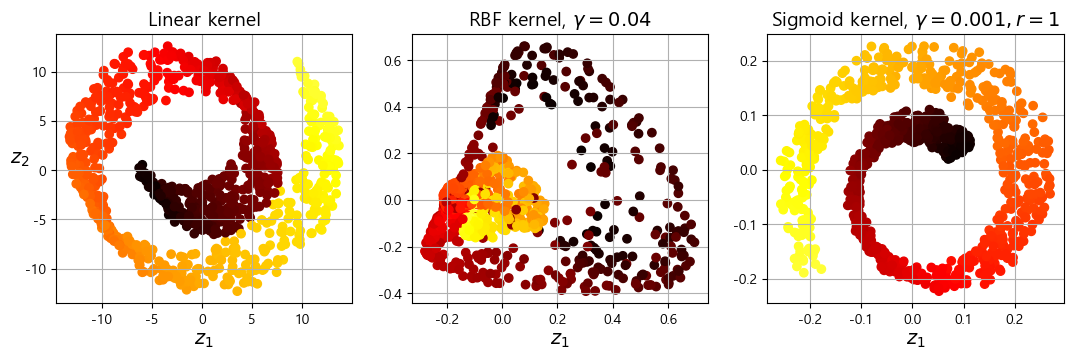

In [19]:
lin_pca = KernelPCA(kernel="linear")
rbf_pca = KernelPCA(kernel="rbf", gamma=0.04)
sig_pca = KernelPCA(kernel="sigmoid", gamma=10**-3, coef0=1)

kernel_pcas = ((lin_pca, "Linear kernel"),
               (rbf_pca, rf"RBF kernel, $\gamma={rbf_pca.gamma}$"),
               (sig_pca, rf"Sigmoid kernel, $\gamma={sig_pca.gamma}, r={sig_pca.coef0}$"))

plt.figure(figsize=(13, 3.5))
for idx, (kpca, title) in enumerate(kernel_pcas):
    kpca.n_components = 2
    kpca.random_state = 42
    X_reduced = kpca.fit_transform(X_swiss)

    plt.subplot(1, 3, idx + 1)
    plt.title(title)
    plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=t, cmap=darker_hot)
    plt.xlabel("$z_1$")
    if idx == 0:
        plt.ylabel("$z_2$", rotation=0)
    plt.grid()

plt.show()

차원 축소는 근본적으로 정답이 없는 비지도 학습이기 때문에, 하이퍼파라미터의 선택에 정답이 없다. 하지만 차원 축소가 지도 학습에서 차원을 축소하고 모델링을 실시하는 경우, 그리드 서치를 사용하여 모델 예측 성능에 가장 좋은 하이퍼파라미터를 선택하는 방법이 있다.

다음 코드는 먼저 KPCA로 차원으로 2차원으로 축소하고, 로지스틱 회귀로 분류를 수행하며, `GridSearchCV`로 분류를 위한 하이퍼파라미터를 탐색하는 파이프라인을 만든다.

```python
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

clf = Pipeline([
    ('kpca',KernelPCA(n_components=2)),
    ('log_reg',LogisticRegression())
    ])

param_grid = [{
    "kpca__gamma": np.linspace(0.03, 0.05, 10),
    "kpca__kernel": ["rbf", "sigmoid"]
    }]

grid_search = GridSearchCV(clf, param_grid, cv=3)
grid_search.fit(X, y)
```

이번엔 단순히 차원 축소가 목적인 경우, 하이퍼파라미터를 선택하는 다른 방법으로 **원래의 차원으로 되돌릴 때 가장 낮은 재구성 오차를 산출하는 하이퍼파라미터를 선택하는 것이다.**  
하지만 커널 PCA에서 원래의 차원으로 복원하는 것은 일반적인 PCA와 비교가 안될 정도로 힘들다.

<center>

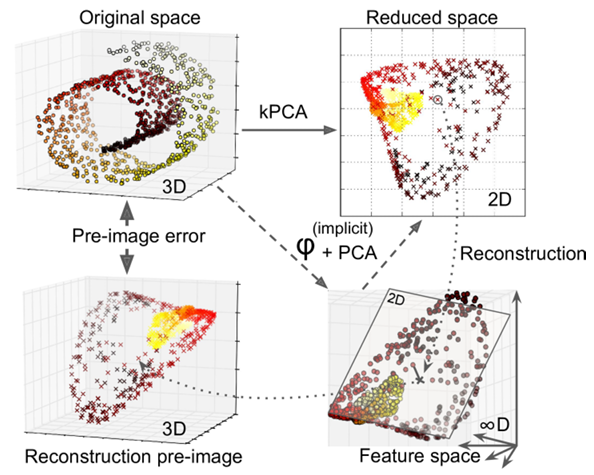

</center>

다음 그림에선 3차원 스위스롤을 RBF 커널을 사용한 KPCA로 2차원으로 매핑했다. 커널 트릭은 수학적으로 매핑 함수 $\phi$로 원본 데이터셋을 무한 차원의 공간을 매핑하고, 변환된 데이터 샘플에 PCA를 적용하여 2차원에 투영하는 것과 동일하다.

일반적인 PCA가 고차원을 주성분으로 투영해 저차원으로 줄이고, 다시 선형 결합으로 원래의 고차원 공간을 비교적 온전히 재구성하여 복원된 샘플과 복원 이전 샘플의 차이를 계산하여 재구성 오차를 정의할 수 있는 반면, KPCA에선 복원이 불가능하다.

이 문제를 해결하기 위해, 저차원 표현과 가장 잘 대응되는 입력 공간상의 점을 찾는 방법이 사용된다. 이를 재구성 pre-image라고 하며, 이렇게 찾은 점과 원래 데이터 사이의 거리(norm)를 측정하여 pre-image 재구성 오차를 계산할 수 있다. 이 오차를 최소화하는 커널과 하이퍼파라미터 조합을 선택함으로써, 비지도 학습 환경에서도 효과적인 차원 축소가 가능하다.

이러한 재구성을 하는 방법으로, `KernelPCA`에서 `fit_inverse_transform=True`로 설정하면 된다.

In [21]:
rbf_pca = KernelPCA(n_components=2, kernel='rbf',gamma=0.04,
                    fit_inverse_transform=True)
X_reduced = rbf_pca.fit_transform(X_swiss)
X_preimage = rbf_pca.inverse_transform(X_reduced)

다음과 같이 재구성 pre-image 오차를 얻을 수 있다.

In [22]:
from sklearn.metrics import mean_squared_error
mean_squared_error(X_swiss, X_preimage)

31.833632434626313

이제 이 오차를 최소화하는 하이퍼파라미터 조합을 찾기 위해 그리드 서치와 같은 방법을 사용하면 된다.

---

## 8.5 랜덤 투영

이름에서 알 수 있듯이 랜덤 투영 알고리즘은 랜덤한 선형 투영을 사용하여 데이터를 저차원 공간에 투영한다. 존슨과 린덴스트라우스가 유명한 정리를 통해 수학적으로 증명한 것처럼 이러한 랜덤한 투영은 실제로 거리를 상당히 잘 보존할 가능성이 매우 높다는 것이 밝혀졌다. 따라서 투영 후에도 비슷한 두 개의 샘플은 비슷한 채로 남고 매우 다른 두 개의 샘플은 다른 채로 남는다.

당연히 더 많은 차원을 삭제할수록 더 많은 정보가 손실되고 더 많은 거리가 왜곡된다. 존슨과 린덴스트라우스는 거리가 주어진 허용 오차 이상으로 변하지 않도록 높은 확률로 보장하기 위해 보존할 최소 차원 수를 결정하는 방식을 고안했다.

예를 들어 각각 $n=20000$개의 변수와 $m=5000$개의 샘플로 구성된 데이터셋이 있고 두 샘플 간의 제곱 거리가 $\epsilon=10%$를 초과하여 변경되지 않도록 하려면 데이터를 $d \ge 4\log(m) \ /\  (1/2\epsilon^2-1/3\epsilon^3)$인 $d$, 즉 7300개 차원으로 투영해야 된다.

이는 상당히 큰 차원의 감소이다. 이 방정식은 $n$을 사용하지 않고 $m$과 $\epsilon$에만 의존한다. 이 방정식은 `johnson_linderstrauss_min_dim()` 함수에 구현되어 있다.

In [16]:
from sklearn.random_projection import johnson_lindenstrauss_min_dim
m,e= 5_000,0.1
d = johnson_lindenstrauss_min_dim(m,eps=e)
d

7300

이제 각 항목을 평균 0, 분산 $1/d$의 가우스 분포에서 랜덤 샘플링한 [$d,n$] 크기의 랜덤 행렬 $\mathbf{P}$를 생성하고 이를 사용하여 데이터셋을 $n$차원에서 $d$차원으로 투영할 수 있다.

In [17]:
n=20_000
np.random.seed(42)
P = np.random.randn(d,n) / np.sqrt(d) # 표준편차

X = np.random.randn(m,n)
X_reduced = X @ P.T

알고리즘이 랜덤한 행렬을 생성하는 데 필요한 것은 데이터셋의 크기뿐이므로 간단하고 효율적이며 훈련이 필요하지 않다. 데이터 자체는 전혀 사용되지 않는다.

사이킷런은 방금 한 것과 정확히 같은 작업을 수행할 수 있는 `GaussianRandomProjection` 클래스를 제공한다. 이 클래스의 `fit()` 메서드를 호출하면 `johnson_lindenstrauss_min_dim()`을 사용해 출력 차원을 결정한 다음 랜덤한 행렬을 생성하여 `components_` 속성에 저장한다. 그런 다음 `transform()`을 호출하면 이 행렬을 사용하여 투영을 수행한다. 이 변환기를 만들 때 $\epsilon$을 조정하려면 `eps` 파라미터를 설정하고 (기본값=0.1) 특정 차원 $d$를 강제로 적용하려면 `n_components` 파라미터를 설정할 수 있다.

다음 코드 예제는 이전 코드와 동일한 결과를 제공한다.

In [18]:
from sklearn.random_projection import GaussianRandomProjection

gaussian_rnd_proj = GaussianRandomProjection(eps=e,random_state=42)
X_reduced = gaussian_rnd_proj.fit_transform(X)

사이킷런은 `SparseRandomProjection`이라는 두 번째 랜덤 투영 변환기도 제공한다. 이 변환기는 동일한 방식으로 타깃 차원을 결정하고 동일한 랜덤 행렬을 생성한 후 투영을 동일하게 수행한다. 가장 큰 차이점은 핸덤 행렬이 희소하다는 것이다. 이전 예제에서 거의 1.2GB가 사용되던 메모리가 약 25MB로 훨씬 적게 사용된다. 또한 랜덤 행렬을 생성하고 차원을 줄이는 데 있어서도 훨씬 빠르다. 입력이 희소할 경우 이 변환은 희소성을 유지한다(`dense_output=True`로 설정하지 않은 경우)

마지막으로 이전 접근 방식과 동일한 거리 보존 속성을 가지며 차원 축소 품질도 비슷하다. 일반적으로 규모가 크거나 희박한 데이터셋의 경우 첫 번째 변환기 대신 해당 변환기를 사용하는 것이 더 바람직하다.

희소한 랜덤 행렬에서 0이 아닌 항목의 비율 $r$을 밀도(density)라고 한다. 기본적으로 밀도는 $1/\sqrt n$이다. 20000개의 변수를 사용하면 랜덤 행렬의 141개 항목 중 1개만 0이 아니라는 뜻으로, 매우 희소하다.

원하는 경우 `density` 파라미터를 다른 값으로 설정할 수 있다. 희소 랜덤 행렬의 각 항목은 0이 아닐 확률 $r$을 가지며, 0이 아닌 각 값은 -$v$ 또는 +$v$ (둘 다 동일 확률)이며, 여기서 $v=1/\sqrt{dr}$이다.

역변환을 수행하려면 먼저 `scipy`의 `pinv()` 함수를 사용하여 성분 행렬의 유사역행렬을 계산한 다음, 축소된 데이터에 유사역행렬의 전치를 곱해야 한다.

In [19]:
components_pinv = np.linalg.pinv(gaussian_rnd_proj.components_)
X_recovered = X_reduced @ components_pinv.T

요약하자면, 랜덤 투영은 간단하고 빠르며 메모리 효울이 높은 강력한 차원 축소 알고리즘으로, 특히 고차원 데이터셋을 다룰 때 염두에 두어야 한다.

---

## 8.6 지역 선형 임베딩

**지역 선형 임베딩(Locally Linear Embedding,LLE)** 은 비선형 차원 축소 기법이다. PCA나 랜덤 투영과는 달리 투영에 의존하지 않는 매니폴드 학습이다. LLE는 먼저 각 훈련 샘플이 최근접 이웃에 얼마나 선형적으로 연관되어 있는지 측정한다. 그런 다음 국부적인 관계가 잘 보존되는 훈련 세트의 저차원 표현을 찾는다. 이 방법은 잡음이 많지 않은 경우 꼬인 매니폴드를 펼치는데 좋다.

다음 코드는 스위스 롤을 만든 다음 사이킷런의 `LocallyLinearEmbedding`을 사용해 이를 펼친다.

In [ ]:
from sklearn.datasets import make_swiss_roll
from sklearn.manifold import LocallyLinearEmbedding

## 데이터 생성
X_swiss, t = make_swiss_roll(n_samples=1000, noise=0.2, random_state=42)

## LLE
lle = LocallyLinearEmbedding(n_components=2, n_neighbors=10, random_state=42) ## 10개 최근접 이웃
X_unrolled = lle.fit_transform(X_swiss)

변수 $t$는 스위스 롤의 회전 축을 따라 각 샘플의 위치를 포함하는 1차원 넘파이 배열이다. 이 예제에서는 사용하지 않지만, 비선형 회귀 작업의 타겟으로 사용할 수 있다.

다음은 결과인 2차원 데이터셋이다.

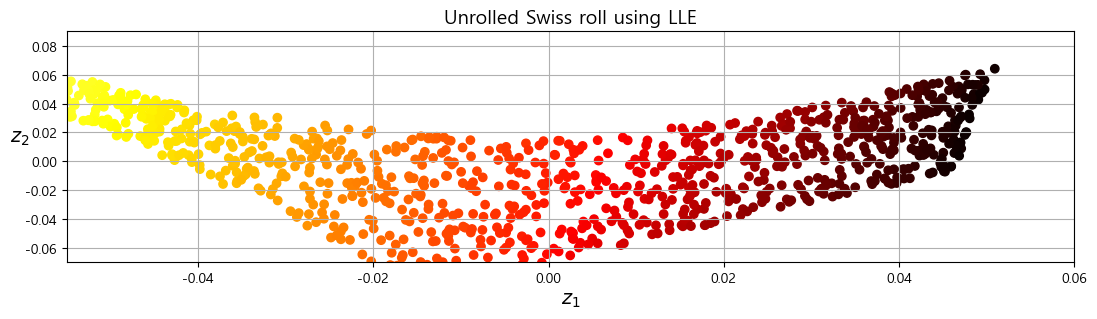

In [11]:
fig = plt.figure(figsize=(13,3))

plt.scatter(X_unrolled[:, 0], X_unrolled[:, 1],
            c=t, cmap=darker_hot)
plt.xlabel("$z_1$")
plt.ylabel("$z_2$", rotation=0)
plt.axis([-0.055, 0.060, -0.070, 0.090])
plt.grid(True)

plt.title("Unrolled Swiss roll using LLE")
plt.show()

그림에서 볼 수 있듯이 스위스 롤이 완전히 펼쳐졌고 지역적으로는 샘플 간 거리가 잘 보존되어 있다. 그러나 크게 보면 샘플 간 거리가 잘 유지되어 있지 않다. 펼쳐진 스위스 롤은 이런 식으로 늘어나거나 꼬인 밴드가 아닌 직사각형이어야 한다.

그럼에도 불구하고 LLE는 매니폴드를 모델링하는데 잘 작동한다.

### LLE 알고리즘

LLE가 작동하는 방식은 다음과 같다.

#### - LLE step1. 선형적인 지역 관계 모델링
먼저 알고리즘이 각 훈련 샘플 $\mathbf{x}^{(i)}$에 대해 $k$개의 최근접 이웃을 찾는다. 그런 다음, $\mathbf{x}^{(i)}$와 $\sum_{j=1}^{m}w_{ij}\mathbf{x}^{(j)}$ 사이의 제곱 거리가 최소가 되는 $w_{ij}$를 찾아 선형 함수로 $\mathbf{x}^{(i)}$를 재구성한다.  
여기서 $\mathbf{x}^{(j)}$가 $\mathbf{x}^{(i)}$의 가장 가까운 $k$개 이웃 중 하나가 아닌 경우에는 $w_{ij}=0$이다. 그러므로 LLE의 첫 단계는 다음과 같은 제약이 있는 최적화 문제를 푸는 것이다.

$$
\hat{\mathbf{W}} = \underset{\mathbf{W}}{\arg\min} \sum_{i=1}^{m} \left\| \mathbf{x}^{(i)} - \sum_{j=1}^{m} w_{ij} \mathbf{x}^{(j)} \right\|^2
$$

$$
\text{Subject to:}
\begin{cases}
w_{ij} = 0 & \text{if } \mathbf{x}^{(j)} \text{ is not one of the } k \text{ nearest neighbors of } \mathbf{x}^{(i)} \\
\sum_{j=1}^{m} w_{ij} = 1 & \text{for } i = 1, 2, \dots, m
\end{cases}
$$

#### - LLE step2. 관계를 보존하는 차원 축소
위의 최적화 문제를 풀면 가중치 행렬 $\hat{\mathbf{W}}$은 훈련 샘플 사이에 있는 지역 선형 관계를 담고 있다. 이제 가능한 한 이 관계가 보존되도록 훈련 샘플을 저차원인 $d$차원 공간으로 매핑해야 한다.  
$\mathbf{z}^{(i)}$가 $d$ 차원 공간에서 $\mathbf{x}^{(i)}$의 상(image)이라면, 가능한 한 $\mathbf{z}^{(i)}$와 $\sum_{j=1}^{m} \hat{w}_{ij} \mathbf{z}^{(j)}$ 사이의 거리를 최소화해야 한다. 이렇게 하면 다음과 같이 제약이 없는 최적화 문제를 푸는 것으로 바뀐다.

$$
\hat{\mathbf{Z}} = \underset{\mathbf{Z}}{\arg\min} \sum_{i=1}^{m} \left\| \mathbf{z}^{(i)} - \sum_{j=1}^{m} \hat{w}_{ij} \mathbf{z}^{(j)} \right\|^2
$$

첫 번째 단계와 비슷해 보이지만, 샘플을 고정하고 최적의 가중치를 찾는 대신, **반대로 가중치를 고정하고 저차원의 공간에서 샘플 이미지의 최적 위치를 찾는다.** $\mathbf{Z}$는 모든 $\mathbf{z}^{(i)}$를 포함하는 행렬이다.

### 계산 복잡도

사이킷런이 제공하는 LLE 구현의 계산 복잡도는 $k$개의 최근접 이웃을 찾는 데 $O(m\log(m)\ \times n\log(k))$, 가중치 최적화에 $O(mnk^3)$, 저차원 표현을 만드는 데 $O(dm^2)$이다. 불행하게도 마지막 항의 $m^2$ 때문에 이 알고리즘을 대규모 데이터셋에 적용하기는 어렵다.

LLE는 투영 기법과는 상당히 다르며 훨씬 더 복잡하지만, 데이터가 비선형인 경우 훨씬 더 나은 저차원 표현을 구성할 수 있다.

---

## 8.7 기타 차원 축소 기법

### 다차원 스케일링

**다차원 스케일링(MultiDimensional Scaling,MDS)** 는 고전적인 차원 축소 방법으로, 각 샘플에 대해, 고차원 공간에서의 **샘플 간 거리 정보**가 저차원에서도 최대한 유지되는 축을 찾는 방법이다. 샘플 간 거리 정보를 다양한 척도를 사용할 수 있다는 점이 장점이지만, MDS는 **모든 샘플 간의 거리 정보 중요도가 동일**하다. 그렇기 때문에 가까운 점들 간의 거리 정보보다 멀리 떨어진 점들의 영향력이 크다. 고차원 공간에서 거리는 '가깝다'라는 정보를 제외하면 대부분 차별성이 없는 무의미하게 큰 값일 가능성이 높다.

다음은 사이킷런의 `MDS` 클래스로 차원을 축소하는 코드이다.

In [23]:
from sklearn.manifold import MDS

mds = MDS(n_components=2, normalized_stress=False, random_state=42)
X_reduced_mds = mds.fit_transform(X_swiss)

### ISOMAP

**ISOMAP**은 MDS의 방식과 유사하다. 모든 점 사이의 측지선 거리를 유지하는 방식으로 차원을 축소한다. **측지 거리**란 두 측점 사이의 매니폴드를 따라 이루어진 거리를 의미한다.
<center>

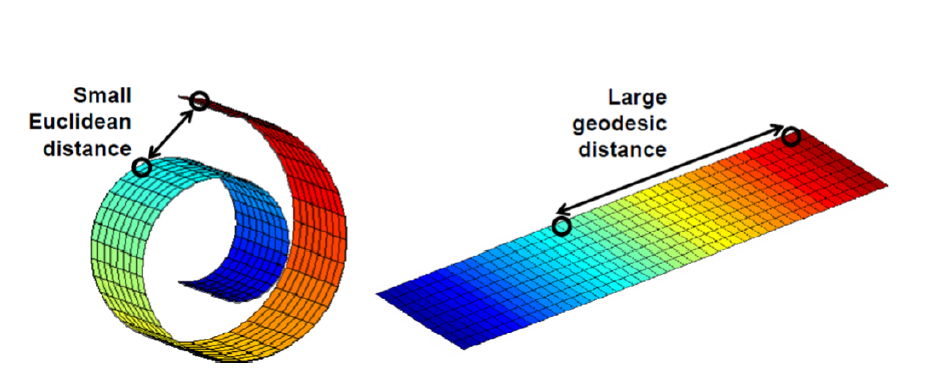

</center>

위 그림에 따르면, 두 점은 유클리드 거리로는 가깝지만, 실제 측지 거리는 상당히 떨어져 있다. ISOMAP 알고리즘은 이러한 데이터의 특징을 반영하여 차원 축소를 진행한다. 기본적으로 ISOMAP은 MDS와 동일한 방식으로 학습하지만, **거리 정보**만 다를 뿐이다.

ISOMAP은 내재된 매니폴드를 잘 반영하여 차원을 축소하며, 비선형적인 데이터 구조에서 상당히 좋은 성능을 보인다. 하지만 내재된 매니폴드가 없을 경우에는 효과적이지 않은 차원 축소 기법이며, 하이퍼파라미터가 존재하여 다양한 하이퍼파라미터 조합을 시도해야 한다. 무엇보다 계산비용이 매우 크다.

다음은 사이킷런의 `Isomap` 클래스로 차원을 축소하는 코드이다.

In [24]:
from sklearn.manifold import Isomap

isomap = Isomap(n_components=2)
X_reduced_isomap = isomap.fit_transform(X_swiss)

### t-SNE

**t-SNE(t-distributed Stochastic Neighbor Embedding)** 은 **SNE**라는 차원 축소 기법에서 발전한 차원 축소 기법이다. LLE와 유사하게 원래의 공간에서 가까운 샘플들이 축소된 공간에서도 가깝도록 차원 축소를 진행한다. t-SNE와 SNE는 가중치를 부여하는 것에서 차이가 있다.

t-SNE는 국부적인 구조를 잘 포착하는 동시에 전역적인 구조 역시 놓치지 않는다. 따라서 자주 사용되는 차원 축소 기법이다. 하지만 **계산 비용이 매우 크다.**

다음은 사이킷런의 `TSNE` 클래스를 사용하여 차원을 축소하는 코드이다.

In [25]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, init="random", learning_rate="auto",
            random_state=42)
X_reduced_tsne = tsne.fit_transform(X_swiss)

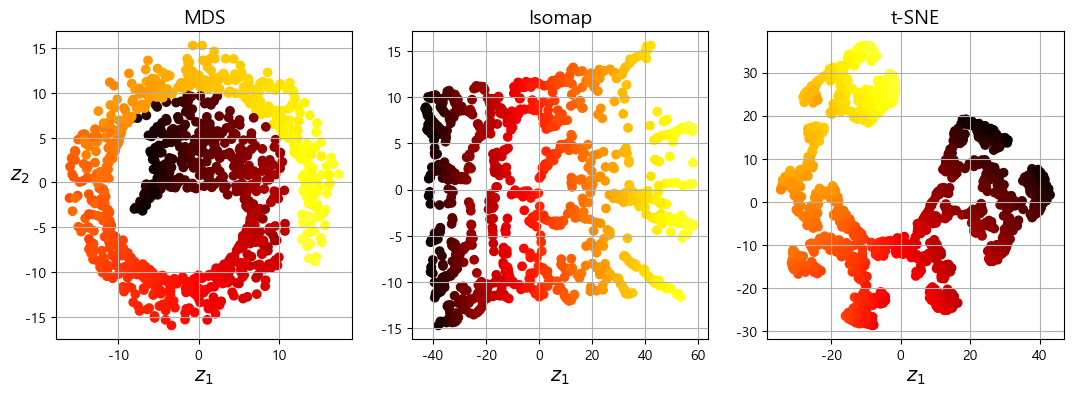

In [26]:
titles = ["MDS", "Isomap", "t-SNE"]

plt.figure(figsize=(13, 4))

for subplot, title, X_reduced in zip((131, 132, 133), titles,
                                     (X_reduced_mds, X_reduced_isomap, X_reduced_tsne)):
    plt.subplot(subplot)
    plt.title(title)
    plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=t, cmap=darker_hot)
    plt.xlabel("$z_1$")
    if subplot == 131:
        plt.ylabel("$z_2$", rotation=0)
    plt.grid(True)

plt.show()

MDS는 전체 곡률을 유지한 채로 스위스롤을 평평하게 만드는 반면, Isomap은 곡률을 완전히 없앤다. 후속 작업에 따라 전체적인 구조를 보존하는 것이 좋을 수도 있고 나쁠 수도 있다. t-SNE는 스위스롤을 평평하게 만들고 약간의 곡률을 보존하는 방식으로 차원 축소를 수행하고 클러스터가 강조되도록 롤을 분해했다.